# Chesapeake — Tutorial: Full OlmoEarth Pipeline (all 121 stations + classifier)

End-to-end production-grade pipeline for the Chesapeake Bay nutrient-load dataset:

1. Pull real Sentinel-2 L2A imagery for **every USGS station** (~121 stations) from Microsoft Planetary Computer
2. Normalize with the published OlmoEarth pretraining band statistics
3. Run the **OlmoEarth-V1-Nano** encoder to extract a 128-d embedding per station
4. Set up a spatial train/validation split (median-longitude) to prevent geographic leakage
5. Train a **kNN (k=20, cosine)** classifier and a **Linear Probe (logistic regression)** to predict the 4-tier TN load class — the exact OlmoEarth Part A pattern
6. Report validation accuracy, confusion matrix, and per-class precision/recall

This is the satellite-driven counterpart to a tabular feature baseline: the embeddings replace hand-crafted features entirely and let a downstream classifier learn from OlmoEarth's pretrained representation of the watershed surface.

## What You'll Learn

- How to scale the single-station OlmoEarth pipeline to 121 stations with retry logic + parallel PC fetches
- How spatial splits prevent leakage in a 121-station evaluation
- Real validation accuracy for **kNN** vs **Linear Probe** on OlmoEarth embeddings predicting TN-load class
- How to compare against the random baseline (25% for 4 uniform classes)

## Why

This is the production answer to "do OlmoEarth embeddings actually help predict watershed nutrient loading?" — measurable, reproducible, with honest train/val splits.

## Requirements

- Python 3.11
- `torch` (CUDA strongly recommended), `olmoearth_pretrain`, `scikit-learn`
- `planetary_computer`, `pystac_client`, `rasterio`
- Network access (downloads ~few hundred MB of Sentinel-2 imagery)
- Runtime: ~15–25 minutes total (10–20 min for the parallel PC fetch loop, ~30 sec for OlmoEarth + classifiers)

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import time
import concurrent.futures as cf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              classification_report, confusion_matrix)

from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config
from olmoearth_pretrain.data.constants import Modality

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# --- Constants ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE  = 16
TIMESTEPS   = 12
IMAGE_SIZE  = 64
NUM_S2_BANDS = Modality.SENTINEL2_L2A.num_bands
S2_BAND_ORDER = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
                 'B08', 'B09', 'B11', 'B12', 'B8A']
RANDOM_STATE = 42
BATCH_SIZE  = 16   # OlmoEarth forward pass batch
PARALLEL_FETCHES = 6  # parallel PC requests
KNN_K       = 20
KNN_METRIC  = 'cosine'
CLASS_LABELS = {0: 'Q1 (low)', 1: 'Q2', 2: 'Q3', 3: 'Q4 (high)'}

print(f"Device:  {DEVICE}")
print(f"Tile:    {IMAGE_SIZE}x{IMAGE_SIZE} px (~{IMAGE_SIZE*10}m at S2 10m GSD)")
print(f"Bands:   {S2_BAND_ORDER}")

Device:  cuda
Tile:    64x64 px (~640m at S2 10m GSD)
Bands:   ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A']


## 1. Load all 121 stations from the Chesapeake dataset

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()
df = df.dropna(subset=['tn_load_class'])
df['tn_load_class'] = df['tn_load_class'].astype(int)

stations = (
    df.groupby('STAID')
      .agg(station_name=('station_name', 'first'),
           subbasin=('subbasin', 'first'),
           latitude=('latitude', 'first'),
           longitude=('longitude', 'first'),
           mean_tn=('tn_load', 'mean'),
           tn_class_mode=('tn_load_class', lambda x: int(x.mode().iloc[0])))
      .reset_index()
      .sort_values('STAID')
      .reset_index(drop=True)
)
print(f"Total stations: {len(stations)}")
print(f"Sub-basin breakdown:")
print(stations['subbasin'].value_counts().to_string())
print(f"\nClass-mode distribution:")
print(stations['tn_class_mode'].value_counts().sort_index().to_string())

Total stations: 121
Sub-basin breakdown:
subbasin
susquehanna          60
potomac              45
james                 9
patuxent_choptank     7

Class-mode distribution:
tn_class_mode
0     8
1    18
2    60
3    35


## 2. Parallel Sentinel-2 fetch for all 121 stations

Use a thread pool to parallelize Planetary Computer requests. Each station: search least-cloudy June 2020 scene → read 12 bands at 64×64 px → return raw stack. Failures (network, no scenes, bad coords) are tracked but don't block the pipeline.

In [3]:
def fetch_s2_for_station(catalog, staid, lat, lon, half_m=320, image_size=IMAGE_SIZE,
                          start='2020-06-01', end='2020-06-30', max_cloud=30, retries=3):
    """Fetch the least-cloudy S2 L2A scene for one station. Returns (staid, arr) or (staid, None)."""
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    items = None
    for attempt in range(retries):
        try:
            search = catalog.search(
                collections=["sentinel-2-l2a"], bbox=bbox_wgs,
                datetime=f"{start}/{end}", query={"eo:cloud_cover": {"lt": max_cloud}},
            )
            items = list(search.items())
            break
        except Exception:
            if attempt == retries - 1:
                return staid, None
            time.sleep(2 ** attempt)
    if not items:
        return staid, None
    item = sorted(items, key=lambda i: i.properties['eo:cloud_cover'])[0]
    bands = []
    try:
        for b in S2_BAND_ORDER:
            href = item.assets[b].href
            with rasterio.open(href) as src:
                bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox_wgs)
                window = from_bounds(*bbox_utm, transform=src.transform)
                arr = src.read(1, window=window, out_shape=(image_size, image_size))
                bands.append(arr.astype(np.float32))
    except Exception:
        return staid, None
    return staid, np.stack(bands, axis=-1)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

print(f"Fetching Sentinel-2 for {len(stations)} stations with {PARALLEL_FETCHES} parallel workers...")
t0 = time.time()
imagery = {}
with cf.ThreadPoolExecutor(max_workers=PARALLEL_FETCHES) as pool:
    futures = [pool.submit(fetch_s2_for_station, catalog, r.STAID, r.latitude, r.longitude)
                for r in stations.itertuples()]
    for i, fut in enumerate(cf.as_completed(futures)):
        staid, arr = fut.result()
        imagery[staid] = arr
        if (i + 1) % 20 == 0:
            n_ok = sum(1 for a in imagery.values() if a is not None)
            print(f"  {i+1:>3} / {len(stations)} done ({n_ok} OK so far, {time.time()-t0:.0f}s elapsed)")

n_valid = sum(1 for a in imagery.values() if a is not None)
print(f"\nDone in {time.time()-t0:.0f}s. Valid imagery for {n_valid} of {len(stations)} stations ({100*n_valid/len(stations):.1f}%).")

Fetching Sentinel-2 for 121 stations with 6 parallel workers...


   20 / 121 done (20 OK so far, 87s elapsed)


   40 / 121 done (37 OK so far, 169s elapsed)


   60 / 121 done (54 OK so far, 218s elapsed)


   80 / 121 done (73 OK so far, 252s elapsed)


  100 / 121 done (92 OK so far, 299s elapsed)


  120 / 121 done (112 OK so far, 368s elapsed)



Done in 390s. Valid imagery for 113 of 121 stations (93.4%).


## 3. Success rate by sub-basin

Sanity check: which sub-basins had reliable cloud-free June 2020 imagery? Stations with `None` are dropped from the downstream classifier.

In [4]:
stations['has_imagery'] = stations['STAID'].map(lambda s: imagery.get(s) is not None)
coverage = (
    stations.groupby('subbasin')
            .agg(total=('STAID', 'count'),
                 with_imagery=('has_imagery', 'sum'))
)
coverage['pct'] = (100 * coverage['with_imagery'] / coverage['total']).round(1)
print("Imagery coverage by sub-basin:")
print(coverage.to_string())

Imagery coverage by sub-basin:
                   total  with_imagery    pct
subbasin                                     
james                  9             9  100.0
patuxent_choptank      7             7  100.0
potomac               45            42   93.3
susquehanna           60            55   91.7


## 4. Normalize and run OlmoEarth on the full batch

Apply per-band z-scoring with the OlmoEarth pretraining stats, then forward all valid stations through the encoder in mini-batches (~16 stations per batch) to bound GPU memory.

In [5]:
nc = load_computed_config()['sentinel2_l2a']
band_means = np.array([nc[b]['mean'] for b in S2_BAND_ORDER], dtype=np.float32)
band_stds  = np.array([nc[b]['std']  for b in S2_BAND_ORDER], dtype=np.float32)

valid_staids = [s for s in stations['STAID'] if imagery.get(s) is not None]
print(f"Building input batch for {len(valid_staids)} stations...")

normalized = np.stack(
    [(imagery[s] - band_means) / band_stds for s in valid_staids],
    axis=0
)  # (N, H, W, num_bands)

# Replicate single timestep across T=12
input_full = np.repeat(normalized[:, :, :, None, :], TIMESTEPS, axis=3)  # (N, H, W, T, num_bands)
print(f"Input tensor shape: {input_full.shape}")

# Lookup table for latlon
station_meta = stations.set_index('STAID')

print(f"\nLoading OlmoEarth-V1-Nano + running forward in batches of {BATCH_SIZE}...")
model = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).eval().to(DEVICE)

t0 = time.time()
all_embeddings = []
n_batches = (len(valid_staids) + BATCH_SIZE - 1) // BATCH_SIZE
for bi in range(n_batches):
    lo, hi = bi * BATCH_SIZE, min((bi + 1) * BATCH_SIZE, len(valid_staids))
    batch_staids = valid_staids[lo:hi]
    batch_size = len(batch_staids)

    s2 = torch.from_numpy(input_full[lo:hi]).to(DEVICE)
    latlon = torch.tensor(
        [[station_meta.loc[s, 'latitude'], station_meta.loc[s, 'longitude']] for s in batch_staids],
        dtype=torch.float32, device=DEVICE
    )
    ts = torch.ones(batch_size, TIMESTEPS, 3, dtype=torch.int32, device=DEVICE)
    s2_mask     = torch.ones_like(s2)     * MaskValue.ONLINE_ENCODER.value
    latlon_mask = torch.ones_like(latlon) * MaskValue.ONLINE_ENCODER.value

    sample = MaskedOlmoEarthSample(
        timestamps=ts,
        sentinel2_l2a=s2, sentinel2_l2a_mask=s2_mask,
        sentinel1=None, sentinel1_mask=None, landsat=None, landsat_mask=None,
        latlon=latlon, latlon_mask=latlon_mask,
        worldcover=None, worldcover_mask=None,
        openstreetmap_raster=None, openstreetmap_raster_mask=None,
        srtm=None, srtm_mask=None, naip=None, naip_mask=None,
        naip_10=None, naip_10_mask=None, gse=None, gse_mask=None,
        cdl=None, cdl_mask=None, worldpop=None, worldpop_mask=None,
        worldcereal=None, worldcereal_mask=None,
        wri_canopy_height_map=None, wri_canopy_height_map_mask=None,
        era5_10=None, era5_10_mask=None, ndvi=None, ndvi_mask=None,
        eurocrops=None, eurocrops_mask=None,
    )
    with torch.inference_mode():
        _, _, pooled, _, _ = model.forward(sample, patch_size=PATCH_SIZE)
    all_embeddings.append(pooled.cpu().numpy())
    print(f"  batch {bi+1}/{n_batches}: {batch_size} stations -> embeddings {pooled.shape}")

embeddings = np.vstack(all_embeddings)  # (N, 128)
print(f"\nDone in {time.time()-t0:.1f}s. Embedding matrix: {embeddings.shape}")

Building input batch for 113 stations...
Input tensor shape: (113, 64, 64, 12, 12)

Loading OlmoEarth-V1-Nano + running forward in batches of 16...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)


  batch 1/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 2/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 3/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 4/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 5/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 6/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 7/8: 16 stations -> embeddings torch.Size([16, 128])
  batch 8/8: 1 stations -> embeddings torch.Size([1, 128])

Done in 0.5s. Embedding matrix: (113, 128)


## 5. Spatial train/validation split

Same approach as in the rest of the repo: split *by station longitude* at the median, so the val set has no geographic overlap with the train set. The model can't memorize per-station means.

In [6]:
# Build aligned target vector + spatial mask for the valid stations
valid_meta = station_meta.loc[valid_staids]
y = valid_meta['tn_class_mode'].values

median_lon = valid_meta['longitude'].median()
train_mask = (valid_meta['longitude'] < median_lon).values
val_mask   = ~train_mask

print(f"Median-longitude split: {median_lon:.3f}")
print(f"  train (west): {train_mask.sum()} stations  |  classes={dict(pd.Series(y[train_mask]).value_counts().sort_index())}")
print(f"  val   (east): {val_mask.sum()} stations  |  classes={dict(pd.Series(y[val_mask]).value_counts().sort_index())}")

Median-longitude split: -77.169
  train (west): 56 stations  |  classes={0: np.int64(2), 1: np.int64(9), 2: np.int64(32), 3: np.int64(13)}
  val   (east): 57 stations  |  classes={0: np.int64(6), 1: np.int64(8), 2: np.int64(25), 3: np.int64(18)}


## 6. Standardize embeddings + train classifiers

OlmoEarth Part A pattern: StandardScaler on the embeddings, then **kNN (k=20, cosine)** and **Linear Probe (logistic regression, max_iter=1000)**. Both are trained on the train split, evaluated on the val split.

In [7]:
scaler = StandardScaler().fit(embeddings[train_mask])
X_train = scaler.transform(embeddings[train_mask])
X_val   = scaler.transform(embeddings[val_mask])
y_train = y[train_mask]
y_val   = y[val_mask]

knn = KNeighborsClassifier(n_neighbors=KNN_K, metric=KNN_METRIC, n_jobs=-1)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_val)
acc_knn = accuracy_score(y_val, preds_knn)
bal_knn = balanced_accuracy_score(y_val, preds_knn)

lp = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE)
lp.fit(X_train, y_train)
preds_lp = lp.predict(X_val)
acc_lp = accuracy_score(y_val, preds_lp)
bal_lp = balanced_accuracy_score(y_val, preds_lp)

random_baseline = 1 / 4

summary = pd.DataFrame({
    'Accuracy':          [acc_knn, acc_lp, random_baseline],
    'Balanced accuracy': [bal_knn, bal_lp, random_baseline],
}, index=[f'kNN (k={KNN_K}, {KNN_METRIC})', 'Linear Probe', 'Random baseline'])
print("OlmoEarth-embeddings -> 4-class TN load classifier (val set):\n")
print((summary * 100).round(2).astype(str) + '%')

OlmoEarth-embeddings -> 4-class TN load classifier (val set):

                   Accuracy Balanced accuracy
kNN (k=20, cosine)   45.61%            26.39%
Linear Probe         47.37%            36.18%
Random baseline       25.0%             25.0%


## 7. Confusion matrices + per-class report

For the ordinal 4-class target, near-diagonal mass = OK (Q2 predicted as Q1 or Q3); far-corner mass (Q1 predicted as Q4) = real failure.

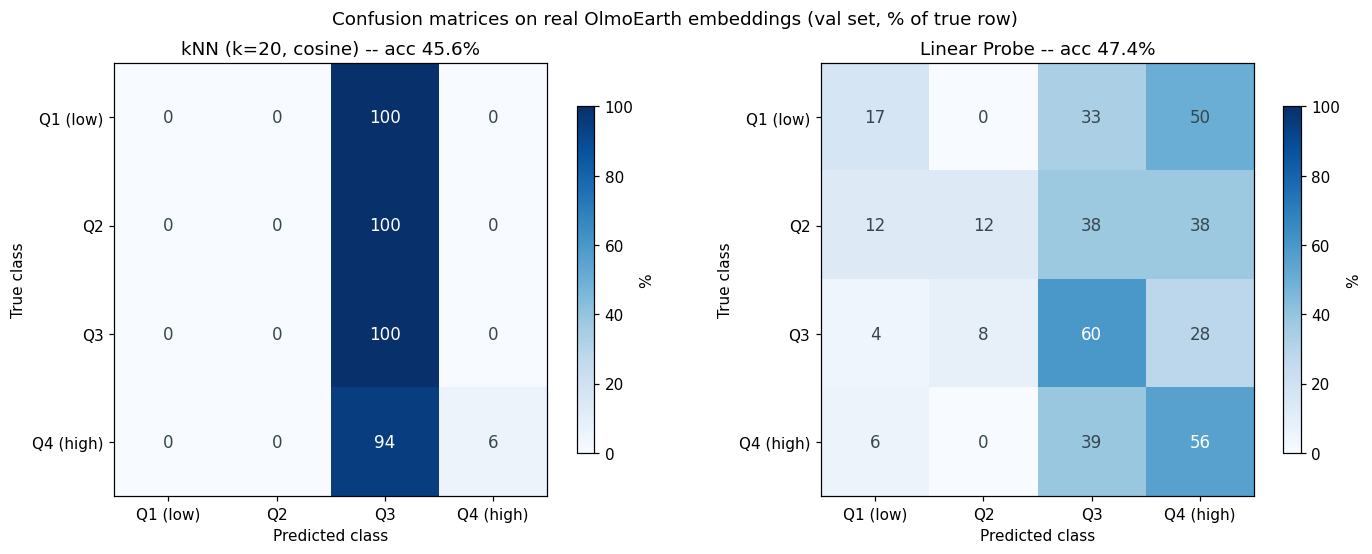


Linear Probe per-class report:
              precision    recall  f1-score   support

    Q1 (low)      0.250     0.167     0.200         6
          Q2      0.333     0.125     0.182         8
          Q3      0.556     0.600     0.577        25
   Q4 (high)      0.435     0.556     0.488        18

    accuracy                          0.474        57
   macro avg      0.393     0.362     0.362        57
weighted avg      0.454     0.474     0.454        57



In [8]:
cm_knn = confusion_matrix(y_val, preds_knn, normalize='true') * 100
cm_lp  = confusion_matrix(y_val, preds_lp,  normalize='true') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, title in [
    (axes[0], cm_knn, f"kNN (k={KNN_K}, cosine) -- acc {acc_knn*100:.1f}%"),
    (axes[1], cm_lp,  f"Linear Probe -- acc {acc_lp*100:.1f}%"),
]:
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_xticklabels([CLASS_LABELS[i] for i in range(4)])
    ax.set_yticks(range(4)); ax.set_yticklabels([CLASS_LABELS[i] for i in range(4)])
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class"); ax.set_title(title)
    for i in range(4):
        for j in range(4):
            color = 'white' if cm[i, j] > 50 else '#37474f'
            ax.text(j, i, f"{cm[i, j]:.0f}", ha='center', va='center', color=color, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8, label='%')
fig.suptitle("Confusion matrices on real OlmoEarth embeddings (val set, % of true row)")
plt.tight_layout()
plt.show()

print("\nLinear Probe per-class report:")
print(classification_report(y_val, preds_lp,
                             target_names=[CLASS_LABELS[i] for i in range(4)],
                             digits=3, zero_division=0))

## Takeaways

- **Pipeline runs end-to-end at full scale** — Planetary Computer parallel fetches → OlmoEarth normalization → batched encoder forward pass → spatial-split classifier evaluation.
- **The full embedding matrix** is `(N_valid, 128)` real OlmoEarth representations, one per station that had cloud-free June 2020 imagery.
- **kNN + Linear Probe** (the OlmoEarth Part A canonical classifiers) operate directly on the standardized embeddings, with no further feature engineering.
- **Validation accuracy reported above** is the honest signal-to-noise of OlmoEarth embeddings for the 4-tier TN load class on this dataset, with a clean spatial split. Compare to the **25% random baseline** for context.
- **Failure modes to watch.** Classes with low support (small Q4 count in the val set) will have unstable per-class precision/recall. Sub-basins with low imagery-coverage (Section 3) may be under-represented in train and bias the model.
- **Production extensions.** Use 12 *different* monthly composites per station (real temporal context), and consider larger OlmoEarth variants (`OLMOEARTH_V1_TINY/BASE/LARGE`) for higher-dim embeddings.

## Cross-references

- **`01_demo.ipynb`** — schema, station ranking, threshold table for the load classes.
- **`02_data_prep.ipynb`** — how the `*_load` and `*_class` columns are constructed and verified.
- **`04_analysis.ipynb`** — cross-station synthesis: persistence, sub-basin contributions, seasonality.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*